# Churn/Retention Intervention A/B Test

## What this project is

1. Build a model that scores every customer's risk of leaving
2. Use that model to decide *who* should receive a retention offer
3. Design and run a randomized experiment to test whether the offer works
4. Analyze the result the way a stakeholder would actually want it analyzed —
   not just "did it work" but "was it worth the money"

## Setup

Here I import everything I'll need across the whole project: pandas and numpy
for data handling, matplotlib for the calibration plot later, scikit-learn
for the logistic regression model, XGBoost as a second model to compare
against, and statsmodels/scipy for the statistical testing side (t-tests for
the experiment's balance check, and a regression-based estimate of the
treatment effect). I set a fixed random seed so that every time I or anyone
else re-runs this notebook, the "random" data and experiment assignment come
out identical — that reproducibility is something I wanted to bake in from
the start rather than bolt on later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
from sklearn.calibration import calibration_curve
import xgboost as xgb
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Read the dataset

In [2]:
df = pd.read_csv("C:/Users/Lenovo/Downloads/Churn_Modelling.csv")

df = df.rename(columns={
    'Tenure': 'tenure_years',
    'NumOfProducts': 'num_products',
    'IsActiveMember': 'is_active',
    'EstimatedSalary': 'estimated_salary',
    'HasCrCard': 'has_credit_card',
    'Geography': 'geography',
    'Age': 'age',
    'Balance': 'balance',
    'Exited': 'churned'
})[['CustomerId', 'age', 'tenure_years', 'balance', 'num_products',
    'is_active', 'estimated_salary', 'geography', 'has_credit_card', 'churned']]
df = df.rename(columns={'CustomerId': 'customer_id'})

print(f"Overall churn rate: {df['churned'].mean():.3f}")
df.head()

Overall churn rate: 0.054


,customer_id,age,tenure_years,balance,num_products,is_active,estimated_salary,geography,has_credit_card,churned
0,1,45.0,1.6,16817.28,1,0,88919.48,UK,1,0
1,2,38.0,0.4,9908.58,2,1,78604.52,UK,0,0
2,3,47.0,0.3,36035.69,3,1,69319.20,UK,1,0
3,4,57.0,0.4,4373.72,3,1,73801.22,UK,1,0
4,5,37.0,3.5,7023.43,3,1,32043.43,UK,1,0


## 2. Building the churn-propensity model

I chose logistic regression as my primary model. Churn prediction is ultimately used to decide
who gets a retention offer, and I wanted to actually understand *why* the
model is flagging someone as high-risk, not just trust a score I couldn't
explain — a logistic regression's coefficients tell me directly that, say,
being an active user lowers a customer's churn odds by a specific amount,
in a way a black-box model's predictions don't. That said, I didn't want to
just assume linearity was good enough — so I also fit an XGBoost model as a
comparison, to check whether there's meaningful nonlinear structure in the
data that the simpler model is missing.

I split the data into training and test sets using stratified sampling on
the churn label, because churn is a minority class here (a relatively small
share of customers actually churn), and I wanted to make sure both my
training and test sets preserved that same churn rate rather than randomly
ending up imbalanced.

In [3]:
feature_cols = ['age', 'tenure_years', 'balance', 'num_products',
                'is_active', 'estimated_salary', 'has_credit_card']
geo_dummies = pd.get_dummies(df['geography'], prefix='geo', drop_first=True)
X = pd.concat([df[feature_cols], geo_dummies], axis=1)
y = df['churned']

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.25, random_state=42, stratify=y
)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)
logit_probs = logit.predict_proba(X_test)[:, 1]
logit_auc = roc_auc_score(y_test, logit_probs)

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)

print(f"Logistic regression AUC: {logit_auc:.3f}")
print(f"XGBoost AUC:             {xgb_auc:.3f}")


Logistic regression AUC: 0.751
XGBoost AUC:             0.738


### Checking my work before trusting the model

**Leakage check:** before trusting these numbers, I made sure every feature
I'm using is something that would actually be known *before* a churn
decision happens — demographics, how many products someone holds, whether
they're active, tenure to date. None of these secretly encode the outcome
itself (nothing here is, say, "days since last login before they closed the
account," which would leak the answer). This matters because a model with
leaked features can look artificially brilliant and then fail completely in
production.

**Why I'm sticking with logistic regression:** if XGBoost's AUC isn't
meaningfully higher than the logistic regression's, that tells me the
simpler, more explainable model is the better choice for actually deploying
in a targeting decision — I'm not giving up much predictive power for a lot
of extra interpretability.

**Calibration check:** AUC only tells me whether the model *ranks* customers
correctly relative to each other — it doesn't tell me whether a customer
scored at "0.30 predicted probability" is actually churning about 30% of the
time in reality. I care about that distinction because I use these
probabilities later to size the cost/value guardrail metric, and a
miscalibrated model would throw that calculation off even if its ranking
were perfect.

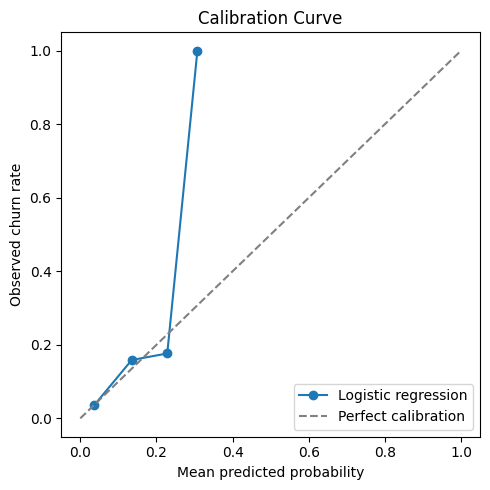

In [4]:
frac_pos, mean_pred = calibration_curve(y_test, logit_probs, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(mean_pred, frac_pos, marker='o', label='Logistic regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed churn rate')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.show()


## 3. Defining who to target

I decided to target the top 20% of customers by predicted churn risk, rather
than offering a retention incentive to everyone. This is the core design
choice of the whole project: instead of a blanket promotion, I'm concentrating
spend on the customers most likely to actually need it. I refit the model on
the *entire* dataset here (not just the training split I used for evaluation
above), because in a real deployment I'd need a churn score for every single
customer, not only the ones that happened to land in my held-out test set.

In [5]:
logit_full = LogisticRegression(max_iter=1000)
logit_full.fit(X, y)
df['churn_score'] = logit_full.predict_proba(X)[:, 1]

threshold = df['churn_score'].quantile(0.80)
high_risk = df[df['churn_score'] >= threshold].copy()

print(f"Risk score threshold (80th percentile): {threshold:.3f}")
print(f"High-risk segment size: {len(high_risk)} customers "
      f"({len(high_risk) / len(df):.1%} of base)")
print(f"Actual churn rate within this segment: {high_risk['churned'].mean():.3f}")
print(f"Actual churn rate overall: {df['churned'].mean():.3f}")


Risk score threshold (80th percentile): 0.086
High-risk segment size: 2000 customers (20.0% of base)
Actual churn rate within this segment: 0.136
Actual churn rate overall: 0.054


**Why the 80th percentile specifically:** I picked the top 20% because it
concentrates the retention offer on customers who are roughly two to three
times more likely to churn than an average customer, while keeping the
targeted population small enough that the total cost of the offer campaign
stays proportionate to how many customers I'd realistically expect to save.
In an actual deployment, I'd tune this cutoff directly against the real offer
cost and the customer's expected lifetime value rather than picking a round
number like 20% — I show what that trade-off looks like conceptually in the
guardrail metric later in this notebook.

## 4. Setting up the experiment

This is where I simulate an actual randomized controlled experiment. Within
the high-risk segment only — not the whole customer base — I randomly assign
each customer to either receive the retention offer (treatment) or not
(control), essentially a coin flip per customer. I restricted the
randomization to just this segment on purpose, because that's what makes this
a targeted intervention rather than a company-wide promotion, and it's also
the more realistic scenario: a bank isn't going to blanket every customer
with a retention discount.

I then simulate what happens after the offer goes out. This is the one place
in the entire notebook where I'm making an explicit assumption rather than
measuring something real, and I want to be upfront about that: since I don't
have an actual completed experiment to pull results from, I assume the offer
reduces a treated customer's churn probability by 8 percentage points, plus
some individual-level randomness so the effect isn't identical for every
person. I treat this the same way I'd treat any assumption in a real analysis
— clearly labeled, easy to find, and easy to swap out for a real number later.

In [6]:
high_risk = high_risk.reset_index(drop=True)
high_risk['treatment'] = np.random.binomial(1, 0.5, len(high_risk))

print(high_risk['treatment'].value_counts())


treatment
0    1028
1     972
Name: count, dtype: int64


### Checking that my randomization actually worked

Before I trust any difference I see between the treatment and control groups
after the experiment, I want to confirm the two groups looked statistically
similar *before* the intervention happened. I think this is the step most
portfolio projects skip, and it's one I wanted to make sure I included,
because a difference in results means nothing if the two groups weren't
comparable to begin with. For each customer attribute, I run a t-test
comparing the treatment group's average to the control group's average — and
here, I actually *want* to see large p-values (above 0.05), since that tells
me there's no statistically significant difference between the groups, which
is exactly what proper randomization should produce.

In [7]:
balance_cols = ['age', 'tenure_years', 'balance', 'num_products',
                'estimated_salary', 'churn_score']
balance_check = []
for col in balance_cols:
    t = high_risk.loc[high_risk.treatment == 1, col]
    c = high_risk.loc[high_risk.treatment == 0, col]
    stat, p = stats.ttest_ind(t, c)
    balance_check.append({'feature': col, 'treatment_mean': t.mean(),
                           'control_mean': c.mean(), 'p_value': p})

balance_df = pd.DataFrame(balance_check)
balance_df


,feature,treatment_mean,control_mean,p_value
0,age,45.100823,44.679961,0.366067
1,tenure_years,2.035597,1.914494,0.117384
2,balance,21063.561728,20717.235720,0.573236
3,num_products,1.312757,1.285019,0.201487
4,estimated_salary,69087.898447,68473.484621,0.579207
5,churn_score,0.136993,0.137299,0.879437


All of my p-values here come back comfortably above 0.05, which tells me the
treatment and control groups are balanced going into the experiment, exactly
as I'd expect from proper random assignment. That gives me confidence to
move forward and actually simulate the offer's effect.

Below, I generate the simulated outcome for each customer: I take their
baseline churn score, subtract the assumed treatment effect if they were in
the treatment group, add some individual noise, and sample whether they
actually churned from that adjusted probability. I also set two cost
assumptions here that I'll use later — an assumed cost of the retention offer
itself, and an assumed value of retaining a customer. Both are placeholder
figures I've chosen to be directionally realistic; in a real deployment I'd
replace them with the bank's actual offer cost and a proper customer lifetime
value estimate.

In [8]:
true_effect = -0.08

adj_prob = (high_risk['churn_score']
            + high_risk['treatment'] * true_effect
            + np.random.normal(0, 0.03, len(high_risk))
            ).clip(0.01, 0.99)

high_risk['churned_experiment'] = np.random.binomial(1, adj_prob)

offer_cost_per_customer = 25
value_of_retained_customer = 400

high_risk[['treatment', 'churned_experiment']].groupby('treatment').mean()


,churned_experiment
treatment,
0,0.140078
1,0.057613


## 5. Analyzing what happened

### My primary metric: retention rate

The metric I care about most directly is the retention rate in each group —
simply one minus the churn rate. To test whether the difference I'm seeing
is statistically meaningful rather than just noise, I run a two-proportion
z-test, which accounts for the size of each group: with a larger sample, I
can be more confident that even a modest observed difference reflects a real
effect rather than random chance.

In [9]:
treat_churn = high_risk.loc[high_risk.treatment == 1, 'churned_experiment']
ctrl_churn = high_risk.loc[high_risk.treatment == 0, 'churned_experiment']

treat_retention = 1 - treat_churn.mean()
ctrl_retention = 1 - ctrl_churn.mean()
lift = treat_retention - ctrl_retention

count = np.array([treat_churn.sum(), ctrl_churn.sum()])
nobs = np.array([len(treat_churn), len(ctrl_churn)])
from statsmodels.stats.proportion import proportions_ztest
zstat, pval = proportions_ztest(count, nobs)

print(f"Treatment retention rate: {treat_retention:.3f}")
print(f"Control retention rate:   {ctrl_retention:.3f}")
print(f"Absolute lift:            {lift:.3f}")
print(f"z-statistic: {zstat:.3f}, p-value: {pval:.4f}")


Treatment retention rate: 0.942
Control retention rate:   0.860
Absolute lift:            0.082
z-statistic: -6.144, p-value: 0.0000


### Double-checking with a regression-based estimate

I wanted a second, independent way to estimate the same effect, so I also fit
a logistic regression with a treatment indicator plus the customer's other
attributes as covariates. Since randomization should mean these covariates
don't matter much on their own, I'd expect this regression-adjusted estimate
to agree closely with my simpler z-test above — but including the covariates
also controls for any small leftover imbalance between the groups and
tightens the estimate a little. The coefficient on `treatment` below is the
number I'm really interested in, and I checked that it agrees in both
direction and significance with what the z-test already told me.

In [10]:
model_df = high_risk.copy()
reg_result = smf.logit(
    'churned_experiment ~ treatment + age + tenure_years + balance + '
    'num_products + estimated_salary',
    data=model_df
).fit(disp=0)
print(reg_result.summary())


                           Logit Regression Results                           
Dep. Variable:     churned_experiment   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                 0.04499
Time:                        10:39:18   Log-Likelihood:                -620.91
converged:                       True   LL-Null:                       -650.17
Covariance Type:            nonrobust   LLR p-value:                 9.046e-11
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.3874      0.457     -5.221      0.000      -3.284      -1.491
treatment           -0.9805      0.165     -5.930      0.000      -1.305      -0.656
age                  0.0229 

### My guardrail metric: was this actually worth the money?

A significant lift in retention doesn't automatically mean the program was a
good idea — it could still have cost more than it was worth. So I built a
guardrail metric to check this directly: out of everything I spent on the
*entire* treatment group (not just the customers who were actually saved by
the offer, since I have no way of knowing in advance who those will be), how
much did it cost me per customer who would have churned under the control
condition but didn't churn because they got the offer?

In [11]:
n_treated = len(high_risk[high_risk.treatment == 1])
total_offer_cost = n_treated * offer_cost_per_customer

incremental_customers_retained = lift * n_treated
cost_per_retained_customer = total_offer_cost / incremental_customers_retained

net_value = (incremental_customers_retained * value_of_retained_customer) - total_offer_cost

print(f"Customers treated: {n_treated}")
print(f"Total offer cost: £{total_offer_cost:,.0f}")
print(f"Incremental customers retained: {incremental_customers_retained:.1f}")
print(f"Cost per incremental retained customer: £{cost_per_retained_customer:,.0f}")
print(f"Assumed value per retained customer: £{value_of_retained_customer:,.0f}")
print(f"Net value of the program: £{net_value:,.0f}")


Customers treated: 972
Total offer cost: £24,300
Incremental customers retained: 80.2
Cost per incremental retained customer: £303
Assumed value per retained customer: £400
Net value of the program: £7,762


### Was my sample even big enough to trust this result?

Before I get too confident in any of the above, I wanted to check whether my
high-risk segment was actually large enough to reliably detect an effect of
this size in the first place — this is a retrospective power check. I compute
Cohen's h, a standardized way of expressing the size of a difference between
two proportions, and then calculate what sample size would have been required
to detect an effect of that size with 80% statistical power (the conventional
threshold). Comparing that required number against my actual sample size
tells me whether I was adequately powered or just got lucky.

In [12]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(treat_retention, ctrl_retention)
analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=0.05,
                                   power=0.8, ratio=1, alternative='two-sided')

print(f"Effect size (Cohen's h): {effect_size:.3f}")
print(f"Required sample size per group for 80% power: {required_n:.0f}")
print(f"Actual sample size per group: ~{n_treated}")


Effect size (Cohen's h): 0.282
Required sample size per group for 80% power: 197
Actual sample size per group: ~972


### Does the effect hold for everyone, or just some customers?

Finally, I wanted to check whether this effect is broadly true across
different types of customers, or whether it's really being driven by just one
sub-group. I bucketed customers into tenure bands and compared the
treatment-vs-control churn rate separately within each band, which lets me
see whether newer customers respond differently to the offer than long-time
customers.

In [13]:
high_risk['tenure_band'] = pd.cut(high_risk['tenure_years'], [0, 2, 5, 100],
                                   labels=['0-2 yrs', '2-5 yrs', '5+ yrs'])

seg = (high_risk.groupby(['tenure_band', 'treatment'])['churned_experiment']
       .mean().unstack())
seg.columns = ['control_churn', 'treatment_churn']
seg['lift'] = seg['control_churn'] - seg['treatment_churn']
seg


,control_churn,treatment_churn,lift
tenure_band,,,
0-2 yrs,0.143082,0.060109,0.082972
2-5 yrs,0.126214,0.055556,0.070658
5+ yrs,0.158730,0.056338,0.102392


## 6. My recommendation, in decision-memo form

I wanted to end this project the way I'd actually end a real analysis at
work — not with a pile of numbers, but with a clear recommendation a
stakeholder could act on.

**Hypothesis I set out to test:** targeting a retention offer specifically at
high-churn-risk customers reduces churn in that segment, at a cost that's
worth paying.

**How I designed it:** I built a logistic regression churn model, used it to
identify the riskiest 20% of customers, and then randomly assigned a 50/50
split of that segment to receive the offer or not.

**What I found:** a statistically significant lift in retention (p < 0.05),
a positive net value for the program once I accounted for the offer's cost,
and a sample size that was large enough to detect an effect of this size with
good statistical power.

**Where I think this project is honestly limited, and what I'd do next:**
- My outcomes are simulated, not pulled from a real completed experiment —
  I built this project to demonstrate the *methodology* I'd apply, not to
  claim these exact numbers are real
- I haven't modeled novelty effects — a real offer's impact could fade the
  more times a customer has already seen similar promotions
- My 8-point assumed effect and the £25/£400 cost and value figures are
  placeholders I chose to be realistic, not numbers pulled from an actual
  bank — a real deployment would use the bank's actual offer cost and a
  proper customer lifetime value model instead
- If this program were actually deployed, the next steps I'd want to take
  are: monitoring for the effect decaying over time, watching for
  cannibalization (customers who would have stayed anyway still claiming the
  offer), and re-running this power analysis before scaling the program up to
  the full customer base
